# GMMs

GMM is a weighted sum of multiple Gaussian components. The PDF of a GMM is:

$\Large{p(x) = \sum\limits_{i = 1}^{K}\pi_k \mathcal{N}(x|\mu_k \sum_k)}$

*Where,*

K = number of Gaussian Components

$\pi_k$ = weight of the K$^{th}$ Gaussian. Note that, $\sum\limits_{i = 1}^{K}\pi_k = 1$

$\mathcal{L}(x|\mu_k, \sum_k)$ = Gaussian Distribution with mean $\mu_k$ and covariance matrix $\sum_k$


#### The parameters of this expressions are:

$\mu_k = $ The centers of the Gaussian Cluster

$\sum_k$ = The spread or shape of Gaussians

$\pi_k$ = Contribution of each Gaussian


Our objective is to find, the probability of each data point x emerging from each of the Gaussian components.

The estimation of the parameter is necessary for computing this probabilities.

**Also note that GMM is a generative model.** This is making assumptions about how the data is generated.

Parameters are estimated using Maximum Likelihood Estimation (MLE) which adjusts the parameters so that the probability of observing the input data under the model is maximized. For GMMs, we use the **Expectation-Maximization (EM)** algorithm.

- E : The responsibility each Gaussian has for each data point is estimated.
- M : Parameters are updated based on the current responsibilty.

### E Step

$\Large{\mathcal{\gamma}_{ik}}$ = $\Large{\frac{\pi_k\mathcal{L}(x_i|\mu_k, \sum_k)}{\sum\limits_{j = 1}^{K}\pi_j\mathcal{L}(x_I|\mu_j, \sum_k)}}$

This represent the responsibility that Gaussian $K$ takes for point $x_i$

### M Step
- **Update Mean**: $\Large{\mu_k = \frac{\sum\limits_{i = 1}^{N} \mathcal{\gamma_{ik}}x_i}{\sum\limits_{i = 1}^{N}\mathcal{\gamma_{ik}}}}$
- **Update Covariances** : $\Large{\sum_k}$ = $\Large{\frac{\sum\limits_{i = 1}^{N}(x_i - \mu_k)(x_i - \mu_k)^T}{\sum\limits_{i = 1}^{N} \mathcal{\gamma_{ik}}}}$
- **Update Weights**: $\Large{\pi_k}$ = $\Large{\frac{\sum\limits_{i = 1}^{N} \mathcal{\gamma_{ik}}}{N} }$

## MyCode
Let's use this in Iris dataset for clustering

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from scipy.stats import multivariate_normal

In [6]:
iris = load_iris()
X = iris.data
y = iris.target

In [7]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [8]:
K = 3 # For 3 clusters
np.random.seed(42)

means = X[np.random.choice(X.shape[0], K, False)]

In [9]:
covariances = [np.eye(X.shape[1])]*K
weights = np.ones(K)/K

In [10]:
def e_step(X, means, covariances, weights, K):
    N = X.shape[0]
    responsibilities = np.zeros((N, K))
    
    for k in range(K):
        # Calculate Gaussian PDF for each point and each component
        rv = multivariate_normal(mean=means[k], cov=covariances[k])
        responsibilities[:, k] = weights[k] * rv.pdf(X)
    
    # Normalize the responsibilities (ensure that the sum of responsibilities for each point is 1)
    responsibilities /= responsibilities.sum(axis=1)[:, np.newaxis]
    
    return responsibilities

In [11]:
def m_step(X, responsibilities, K):
    N, D = X.shape  # N is number of data points, D is number of features
    
    # Update the means
    means = np.dot(responsibilities.T, X) / responsibilities.sum(axis=0)[:, np.newaxis]
    
    # Update the covariances
    covariances = []
    for k in range(K):
        diff = X - means[k]
        covariances_k = np.dot(responsibilities[:, k] * diff.T, diff) / responsibilities[:, k].sum()
        covariances.append(covariances_k)
    
    # Update the weights
    weights = responsibilities.sum(axis=0) / N
    
    return means, covariances, weights

In [12]:
def log_likelihood(X, means, covariances, weights, K):
    N = X.shape[0]
    log_likelihood = 0
    
    for k in range(K):
        rv = multivariate_normal(mean=means[k], cov=covariances[k])
        log_likelihood += weights[k] * rv.pdf(X)
    
    return np.sum(np.log(log_likelihood))

In [14]:
def gmm_em(X, K, max_iter=100, tol=1e-6):
    # Initialize parameters
    means = X[np.random.choice(X.shape[0], K, replace=False)]
    covariances = [np.eye(X.shape[1])] * K
    weights = np.ones(K) / K
    
    prev_log_likelihood = None
    
    for i in range(max_iter):
        # E-step: Calculate responsibilities
        responsibilities = e_step(X, means, covariances, weights, K)
        
        # M-step: Update parameters
        means, covariances, weights = m_step(X, responsibilities, K)
        
        # Compute log-likelihood for convergence check
        current_log_likelihood = log_likelihood(X, means, covariances, weights, K)
        
        # Check for convergence
        if prev_log_likelihood is not None and abs(current_log_likelihood - prev_log_likelihood) < tol:
            print(f"Converged at iteration {i+1}")
            break
        
        prev_log_likelihood = current_log_likelihood
    
    return means, covariances, weights, responsibilities


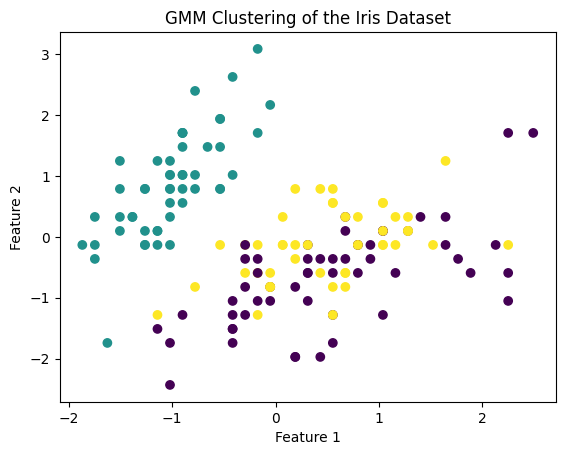

In [15]:
# Fit the GMM to the Iris dataset
means, covariances, weights, responsibilities = gmm_em(X, K=3)

# Predicted cluster labels (for visualization)
labels = np.argmax(responsibilities, axis=1)

# Visualize the clustering
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title("GMM Clustering of the Iris Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Internet Code

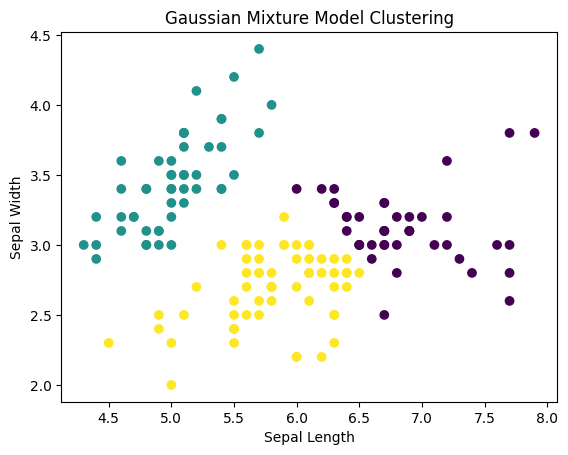

In [16]:
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data[:, :2]  

gmm = GaussianMixture(n_components=3)
gmm.fit(X)

labels = gmm.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Gaussian Mixture Model Clustering')
plt.show()